# Otimização de CNNs para Reconhecimento de Emoções Faciais

In [15]:
import numpy as np 
import pandas as pd
import os

import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras
from keras.preprocessing import image
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Flatten,Dense,Dropout,BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2
from keras import regularizers
from tensorflow.keras.optimizers import Adam,RMSprop,SGD,Adamax

In [16]:
import tensorflow as tf
print("GPUs ativas:", tf.config.list_physical_devices('GPU'))

GPUs ativas: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [17]:
train_dir = "../input/datasets/msambare/fer2013/train" # Directory containing the training data
test_dir = "../input/datasets/msambare/fer2013/test"  # Directory containing the validation data

In [18]:
img_size = 48 #original size of the image

In [21]:
"""
Data Augmentation
--------------------------
"""

train_datagen = ImageDataGenerator(#rotation_range = 180,
                                         width_shift_range = 0.1,
                                         height_shift_range = 0.1,
                                         horizontal_flip = True,
                                         rescale = 1./255,
                                         zoom_range = 0.2,
                                         validation_split = 0.2
                                        )
validation_datagen = ImageDataGenerator(rescale = 1./255,
                                         validation_split = 0.2)

In [22]:
"""
Applying data augmentation to the images as we read 
them from their respective directories
"""
train_generator = train_datagen.flow_from_directory(directory = train_dir,
                                                    target_size = (img_size,img_size),
                                                    batch_size = 64,
                                                    color_mode = "grayscale",
                                                    class_mode = "categorical",
                                                    subset = "training"
                                                   )
validation_generator = validation_datagen.flow_from_directory( directory = test_dir,
                                                              target_size = (img_size,img_size),
                                                              batch_size = 64,
                                                              color_mode = "grayscale",
                                                              class_mode = "categorical",
                                                              subset = "validation"
                                                             )

Found 22968 images belonging to 7 classes.
Found 1432 images belonging to 7 classes.


In [8]:
"""
model = tf.keras.models.Sequential()

# --- Bloco 1 (Figura 5.4): Conv -> MaxPool ---
model.add(Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu',
                  input_shape=(48, 48, 1)))
model.add(MaxPool2D(pool_size=(2, 2)))

# --- Bloco 2: Conv -> MaxPool -> BatchNorm -> Dropout ---
model.add(Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(BatchNormalization())
model.add(Dropout(0.25))

# --- Bloco 3: Conv -> BatchNorm -> MaxPool -> Dropout ---
model.add(Conv2D(128, kernel_size=(5, 5), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# --- Bloco 4: Conv -> BatchNorm -> MaxPool -> Dropout ---
model.add(Conv2D(512, kernel_size=(3, 3), padding='same', activation='relu',
                  kernel_regularizer=regularizers.l2(0.01)))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# --- Camadas densas (Figura 5.4: Flatten -> Dropout -> Dense+ReLU -> Dropout -> Dense+Softmax) ---
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(7, activation='softmax'))

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
"""

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1783599055.393916      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783599055.397021      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [23]:
# --- Nova Arquitetura Proposta ---
model = tf.keras.models.Sequential()

# --- Bloco 1 (Melhorado): Empilhamento de Convoluções para reter detalhes ---
model.add(Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu', input_shape=(48, 48, 1)))
model.add(Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu')) # Nova camada antes do Pooling
model.add(BatchNormalization()) # Adicionado para estabilizar o início da rede
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# --- Bloco 2: Conv -> MaxPool -> BatchNorm -> Dropout ---
model.add(Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(BatchNormalization())
model.add(Dropout(0.25))

# --- Bloco 3: Conv -> BatchNorm -> MaxPool -> Dropout ---
model.add(Conv2D(128, kernel_size=(5, 5), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# --- Bloco 4: Conv -> BatchNorm -> MaxPool -> Dropout ---
model.add(Conv2D(512, kernel_size=(3, 3), padding='same', activation='relu',
                 kernel_regularizer=regularizers.l2(0.01)))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# --- Camadas Densas Classificadoras (Melhoradas com BatchNorm) ---
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(BatchNormalization()) # Adicionado aqui para controlar o overfitting na camada densa
model.add(Dropout(0.3))         # Aumentado levemente de 0.25 para 0.3 para maior regularização

model.add(Dense(7, activation='softmax'))

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
epochs = 60
batch_size = 64

In [26]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 6, 6, 512)      │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 2,008,999 (7.66 MB)

 Trainable params: 2,007,015 (7.66 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [27]:
history = model.fit(x = train_generator,epochs = epochs,validation_data = validation_generator)

Epoch 1/60
359/359 ━━━━━━━━━━━━━━━━━━━━ 54s 117ms/step - accuracy: 0.2369 - loss: 3.1915 - val_accuracy: 0.2877 - val_loss: 2.2350
Epoch 2/60
359/359 ━━━━━━━━━━━━━━━━━━━━ 32s 88ms/step - accuracy: 0.3246 - loss: 2.0227 - val_accuracy: 0.3170 - val_loss: 1.9384
Epoch 3/60
359/359 ━━━━━━━━━━━━━━━━━━━━ 32s 88ms/step - accuracy: 0.4007 - loss: 1.8703 - val_accuracy: 0.3869 - val_loss: 1.9314
Epoch 4/60
359/359 ━━━━━━━━━━━━━━━━━━━━ 32s 90ms/step - accuracy: 0.4458 - loss: 1.7787 - val_accuracy: 0.4860 - val_loss: 1.6809
Epoch 5/60
359/359 ━━━━━━━━━━━━━━━━━━━━ 32s 90ms/step - accuracy: 0.4788 - loss: 1.6667 - val_accuracy: 0.4867 - val_loss: 1.6303
Epoch 6/60
359/359 ━━━━━━━━━━━━━━━━━━━━ 32s 88ms/step - accuracy: 0.4917 - loss: 1.6597 - val_accuracy: 0.5237 - val_loss: 1.5704
Epoch 7/60
359/359 ━━━━━━━━━━━━━━━━━━━━ 34s 94ms/step - accuracy: 0.5051 - loss: 1.6288 - val_accuracy: 0.5482 - val_loss: 1.5757
Epoch 8/60
359/359 ━━━━━━━━━━━━━━━━━━━━ 34s 94ms/step - accuracy: 0.5089 - loss: 1.6216 -

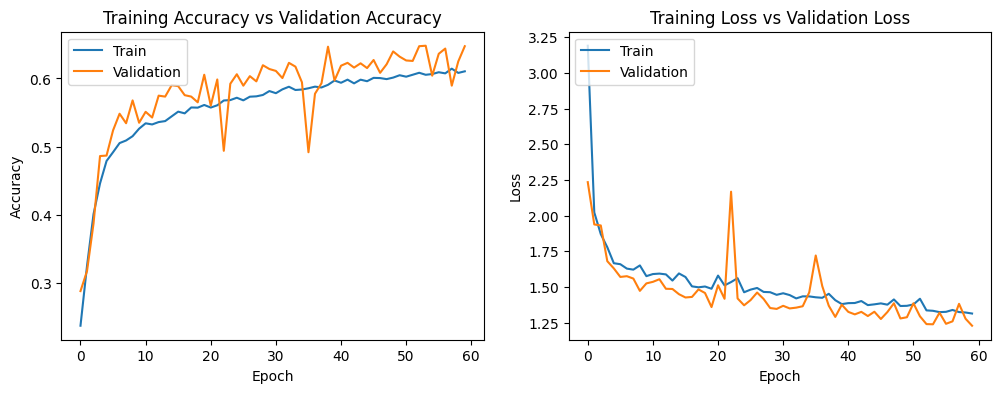

In [28]:
fig , ax = plt.subplots(1,2)
train_acc = history.history['accuracy']
train_loss = history.history['loss']
fig.set_size_inches(12,4)

ax[0].plot(history.history['accuracy'])
ax[0].plot(history.history['val_accuracy'])
ax[0].set_title('Training Accuracy vs Validation Accuracy')
ax[0].set_ylabel('Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].legend(['Train', 'Validation'], loc='upper left')

ax[1].plot(history.history['loss'])
ax[1].plot(history.history['val_loss'])
ax[1].set_title('Training Loss vs Validation Loss')
ax[1].set_ylabel('Loss')
ax[1].set_xlabel('Epoch')
ax[1].legend(['Train', 'Validation'], loc='upper left')

plt.show()

================ ACCURACY E LOSS FINAIS ================
Acurácia Final de Treinamento: 61.05%
Acurácia Final de Validação:   64.73%
Perda (Loss) Final de Treino:  1.3139
Perda (Loss) Final de Val:     1.2284



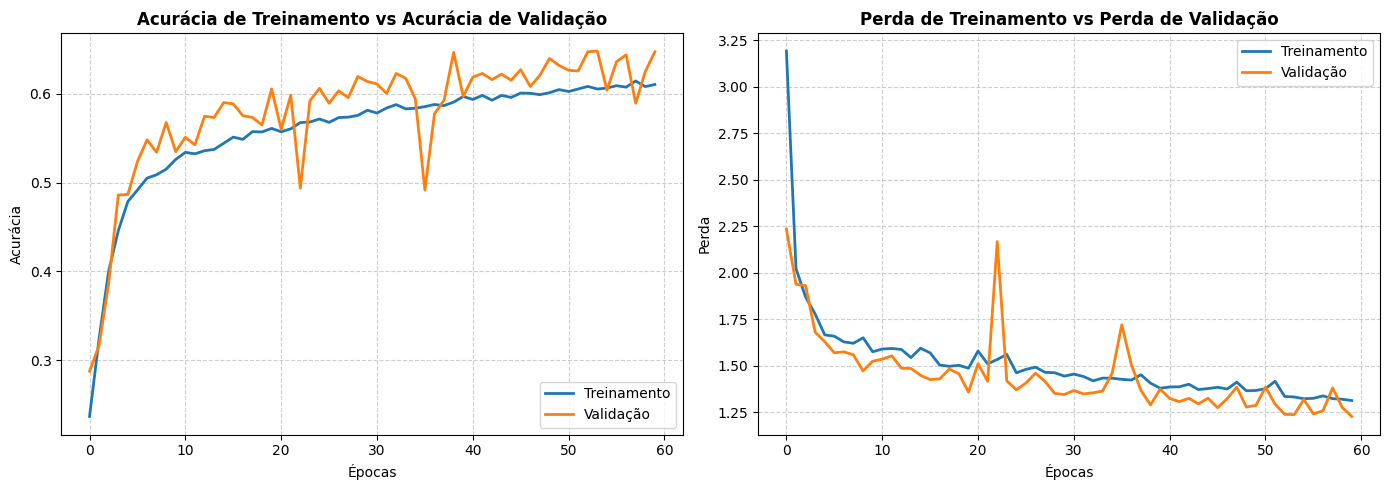


Gerando previsões detalhadas na base de validação...
Found 1432 images belonging to 7 classes.
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step

================ MÉTRICAS DETALHADAS POR CLASSE ================
Classe Emoção  | Precisão   | Recall     | F1-Score  
-------------------------------------------------------
Raiva          |    66.45% |    53.93% |    59.54%
Nojo           |    80.00% |    18.18% |    29.63%
Medo           |    57.28% |    28.92% |    38.44%
Felicidade     |    88.12% |    85.88% |    86.98%
Tristeza       |    51.98% |    80.08% |    63.04%
Surpresa       |    52.94% |    50.60% |    51.75%
Neutro         |    64.73% |    80.72% |    71.85%



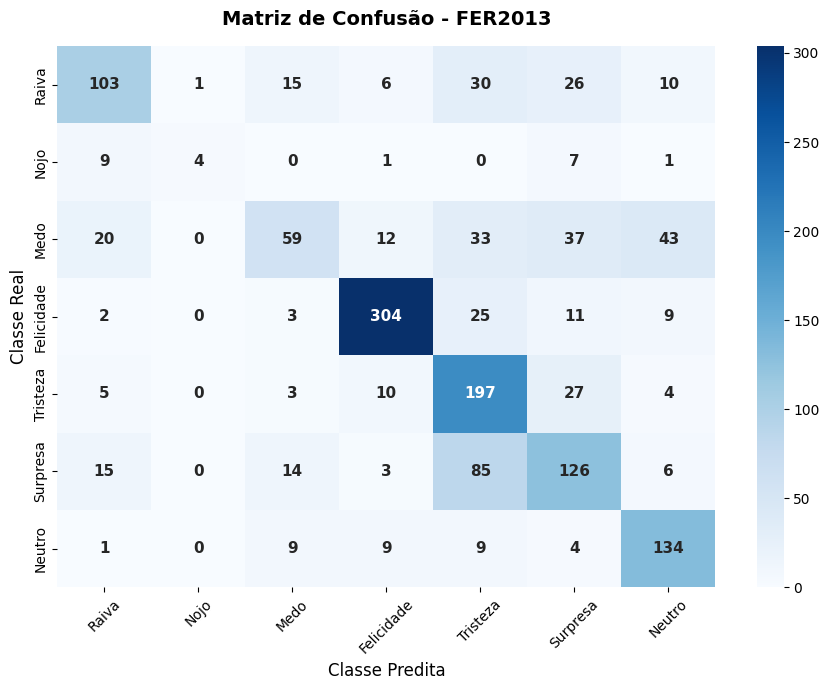

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# --- 1. CONFIGURAÇÕES INICIAIS ---
# Nomes das classes na ordem oficial que o ImageDataGenerator lê as pastas
class_names = ['Raiva', 'Nojo', 'Medo', 'Felicidade', 'Tristeza', 'Surpresa', 'Neutro']


# --- 2. EXIBIR ACURÁCIA FINAL DE TREINAMENTO E VALIDAÇÃO ---
print("================ ACCURACY E LOSS FINAIS ================")
acc_treino = history.history['accuracy'][-1] * 100
acc_val = history.history['val_accuracy'][-1] * 100
loss_treino = history.history['loss'][-1]
loss_val = history.history['val_loss'][-1]

print(f"Acurácia Final de Treinamento: {acc_treino:.2f}%")
print(f"Acurácia Final de Validação:   {acc_val:.2f}%")
print(f"Perda (Loss) Final de Treino:  {loss_treino:.4f}")
print(f"Perda (Loss) Final de Val:     {loss_val:.4f}")
print("========================================================\n")


# --- 3. PLOTAR AS CURVAS DE PERDA (LOSS) E ACURÁCIA ---
plt.figure(figsize=(14, 5))

# Gráfico de Acurácia
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Treinamento', color='#1f77b4', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validação', color='#ff7f0e', linewidth=2)
plt.title('Acurácia de Treinamento vs Acurácia de Validação', fontsize=12, fontweight='bold')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Gráfico de Perda (Loss)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Treinamento', color='#1f77b4', linewidth=2)
plt.plot(history.history['val_loss'], label='Validação', color='#ff7f0e', linewidth=2)
plt.title('Perda de Treinamento vs Perda de Validação', fontsize=12, fontweight='bold')
plt.xlabel('Épocas')
plt.ylabel('Perda')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


# --- 4. PREVISÕES CORRIGIDAS (SEM EMBARALHAMENTO) ---
print("\nGerando previsões detalhadas na base de validação...")

# Criamos um gerador específico para o teste garantindo que o 'shuffle' seja False
# Isso evita que o gabarito das fotos venha embaralhado e estrague a Matriz de Confusão
validation_generator_test = validation_datagen.flow_from_directory(
    directory = test_dir, 
    target_size = (img_size, img_size),
    batch_size = 64,
    color_mode = "grayscale",
    class_mode = "categorical",
    subset = "validation",
    shuffle = False 
)

# O modelo faz a previsão linear na ordem exata das fotos
predictions = model.predict(validation_generator_test, verbose=1)
y_pred = np.argmax(predictions, axis=1)

# Respostas reais extraídas na ordem correta
y_true = validation_generator_test.classes


# --- 5. EXIBIR VALORES EM % (PRECISION, RECALL, F1-SCORE) ---
print("\n================ MÉTRICAS DETALHADAS POR CLASSE ================")
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)

print(f"{'Classe Emoção':<14} | {'Precisão':<10} | {'Recall':<10} | {'F1-Score':<10}")
print("-" * 55)
for classe in class_names:
    p = report[classe]['precision'] * 100
    r = report[classe]['recall'] * 100
    f1 = report[classe]['f1-score'] * 100
    print(f"{classe:<14} | {p:>8.2f}% | {r:>8.2f}% | {f1:>8.2f}%")
print("=================================================================\n")


# --- 6. MATRIZ DE CONFUSÃO (MAPA DE CALOR) ---
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 11, "weight": "bold"})
plt.title('Matriz de Confusão - FER2013', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Classe Real', fontsize=12)
plt.xlabel('Classe Predita', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [48]:
model.save('modelo_novo_augmentation.keras')

In [1]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [28]:
model.save('model_optimal.h5')

In [29]:
img = image.load_img("../input/emotion-detection-fer/test/happy/im1021.png",target_size = (48,48),color_mode = "grayscale")
img = np.array(img)
plt.imshow(img)
print(img.shape) #prints (48,48) that is the shape of our image

FileNotFoundError: [Errno 2] No such file or directory: '../input/emotion-detection-fer/test/happy/im1021.png'

In [ ]:
label_dict = {0:'Angry',1:'Disgust',2:'Fear',3:'Happy',4:'Neutral',5:'Sad',6:'Surprise'}

In [ ]:
img = np.expand_dims(img,axis = 0) #makes image shape (1,48,48)
img = img.reshape(1,48,48,1)
result = model.predict(img)
result = list(result[0])
print(result)

In [ ]:
img_index = result.index(max(result))
print(label_dict[img_index])
plt.show()

In [30]:
train_loss, train_acc = model.evaluate(train_generator)
test_loss, test_acc   = model.evaluate(validation_generator)
print("final train accuracy = {:.2f} , validation accuracy = {:.2f}".format(train_acc*100, test_acc*100))

359/359 ━━━━━━━━━━━━━━━━━━━━ 40s 112ms/step - accuracy: 0.8927 - loss: 0.6211
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 0.6271 - loss: 1.4053
final train accuracy = 89.27 , validation accuracy = 62.71


In [ ]:
model.save_weights('model_weights.h5')